In [1]:
import os
import sys

In [2]:
import pathlib
import math
import numpy as np
import matplotlib.pyplot as plt
import qpc.tools as tools
from qpc.tools import mv
from qpc import evolution
from concurrent.futures import ProcessPoolExecutor

In [3]:
ed_list = np.linspace(-1, 2, num=30)

In [4]:
e = 1     # on-site energy
h = 0.05  # hopping

ns = 200 # number of sites in a single lead

e_ = [e]*ns
h_ = [h]*ns
chain = np.column_stack((e_, h_))
chain[0,1] = h # coupling to QPC

In [5]:
# save chain parameters
np.savetxt('./chain.txt', chain, delimiter=' ')

In [6]:
dt = 0.01

In [7]:
# find the light cone
!qpc-prepare.py --tmax=800 --rtol=1E-5 --dt=0.01 --ringmax=5 --fout=lc

Wellcome to lightcone constructor version 01.03.2023-14.44
Semiinfinite chain file:  chain.txt
Length of chain:  200
Relative significance treshold for forward lightcone boundary:  1e-05
Maximal size of ring:  5
Maximal time:  800.0
Time step:  0.01
Coupling to impurity:  0.05
The execution time : 88.34469532966614  sec


In [ ]:
import numpy as np
import subprocess
from concurrent.futures import ProcessPoolExecutor

# 1. Функция для запуска одной задачи
def run_quantum_job(var):
    # Формируем команду (f-строка подставит значение var)
    command = [
        "qpc-solve.py",
        "--maxcores=1", 
        "--cfrom=5", 
        "--cto=5", 
        "--csize=1", 
        "--U=1", 
        f"--e_d={var}", # Подставляем e_d
        "--fin=lc", 
        f"--fout=result_{var:.4f}", # Уникальное имя для каждого файла вывода
        "--nquanta=7", 
        "--tmax=800",
        "--A=0.1",
        "--w=0.5"
    ]
    
    print(f"Starting job for e_d = {var:.4f}")
    subprocess.run(command)
    return f"Done: {var}"

# 2. Запуск параллельно (например, в 4 потока/процесса)
# max_workers — сколько ядер выделить на параллельный запуск
with ProcessPoolExecutor(max_workers=30) as executor:
    results = list(executor.map(run_quantum_job, ed_list))

print("All jobs finished.")

Starting job for e_d = -0.7931Starting job for e_d = -1.0000Starting job for e_d = -0.8966Starting job for e_d = -0.6897Starting job for e_d = -0.5862Starting job for e_d = -0.3793Starting job for e_d = -0.1724Starting job for e_d = 0.2414Starting job for e_d = -0.4828Starting job for e_d = -0.2759
Starting job for e_d = 0.5517Starting job for e_d = 0.1379Starting job for e_d = -0.0690Starting job for e_d = 0.0345

Starting job for e_d = 0.4483Starting job for e_d = 0.3448Starting job for e_d = 0.7586Starting job for e_d = 0.8621
Starting job for e_d = 1.0690Starting job for e_d = 0.6552
Starting job for e_d = 0.9655
Starting job for e_d = 1.3793Starting job for e_d = 1.1724
Starting job for e_d = 1.2759



Starting job for e_d = 1.4828




Starting job for e_d = 1.8966Starting job for e_d = 2.0000
Starting job for e_d = 1.7931










Starting job for e_d = 1.5862
Starting job for e_d = 1.6897
Wellcome to lightcone impurity solver version 10.03.2023-11.51
Will read the lightcone inf

In [11]:
import numpy as np
import os
import pathlib

J_lc = []

for var in ed_list:
    folder = f"result_{var:.4f}"
    path_x = pathlib.Path(os.getcwd()) / folder / "x_5.txt"
    
    try:
        # Загружаем данные (первая колонка - Re, вторая - Im)
        xc = np.loadtxt(path_x)
        
        # Создаем комплексный массив x нужной длины
        # (Обычно длина совпадает с количеством строк в xc - 1)
        x = xc[1:, 0] + 1j * xc[1:, 1]
        
        # Ваша формула расчета (индексы 79900 и 10000)
        # ВАЖНО: убедитесь, что в x достаточно элементов для этих индексов
        val_799 = x[799 * 100]
        val_100 = x[100 * 100]
        
        current_j = (val_799 - val_100) / (699 * 100 * dt)
        J_lc.append(current_j)
        
    except Exception as e:
        print(f"Ошибка в папке {folder}: {e}")
        J_lc.append(np.nan) # Заполняем пропуском, если файл битый или отсутствует

# Превращаем в итоговый массив
J_lc = np.array(J_lc)


/tmp/ipykernel_205306/3904405644.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'e_d')

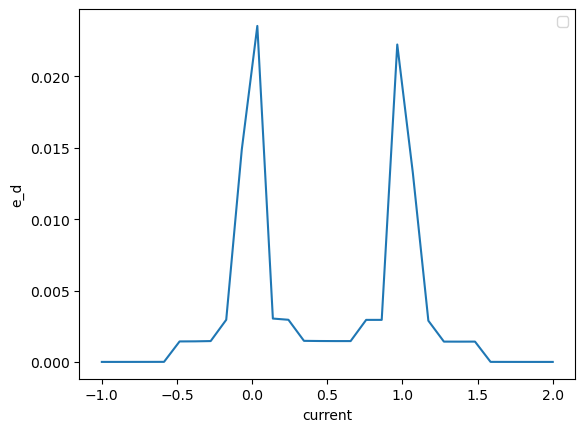

In [13]:
plt.plot(ed_list, J_lc)
plt.legend()
plt.xlabel('current')
plt.ylabel('e_d')